## Install & Import Libraries

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

# Feature importance
from sklearn.inspection import permutation_importance

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load & Check Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Satya/Life Style Data.csv')

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Daily meals frequency,Physical exercise,Carbs,Proteins,Fats,Calories,meal_name,meal_type,diet_type,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle,Workout,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,26.800377,1.50,3.99,2.01,24.87,2.99,0.01,267.68,106.05,71.63,1806.0,Other,Lunch,Vegan,31.77,1729.94,285.05,120.47,Grilled,16.24,110.79,1.31,Decline Push-ups,4.99,20.91,Improves shoulder health and posture,342.58,"Shoulders, Triceps",Cable Machine,Advanced,Legs,Lats,Dumbbell flyes,24.870447,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,27.655021,1.90,4.00,2.01,23.48,3.01,0.97,214.32,85.41,56.97,1577.0,Other,Lunch,Vegetarian,12.34,693.08,300.61,109.15,Fried,16.47,12.01,1.92,Bear Crawls,4.01,16.15,Strengthens lower abs,357.16,"Back, Core, Shoulders",Step or Box,Intermediate,Chest,Lats,Lateral raises,23.479709,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,24.320821,1.88,2.99,1.02,21.15,1.99,-0.02,246.04,98.11,65.48,1608.0,Other,Breakfast,Paleo,42.81,2142.48,215.42,399.43,Boiled,54.35,6.09,4.70,Dips,5.00,21.90,Builds chest strength,359.63,"Quadriceps, Glutes",Step or Box,Intermediate,Arms,Grip Strength,Standing calf raises,21.148123,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,32.813572,2.50,3.99,1.99,32.45,3.00,0.04,203.22,80.84,54.56,2657.0,Other,Lunch,Paleo,9.34,123.20,9.70,314.31,Fried,27.73,103.72,4.85,Mountain Climbers,4.01,16.92,Improves coordination and cardiovascular health,351.65,"Biceps, Forearms",Parallel Bars or Chair,Advanced,Shoulders,Upper,Incline dumbbell flyes,32.449827,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,17.307319,2.91,4.00,2.00,14.83,3.00,3.00,332.79,133.05,88.43,1470.0,Other,Breakfast,Vegan,23.78,1935.11,116.89,99.22,Baked,34.16,46.55,3.07,Bicep Curls,4.99,15.01,Targets obliques and improves core rotation,329.36,"Chest, Triceps",Wall,Advanced,Abs,Wrist Flexors,Military press,14.831372,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

In [ ]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Daily meals frequency,Physical exercise,Carbs,Proteins,Fats,Calories,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,prep_time_min,cook_time_min,rating,Sets,Reps,Burns Calories (per 30 min),BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,38.851453,73.898832,1.723093,179.889702,143.704306,62.195813,1.259446,1280.109600,26.101313,2.627485,3.318629,1.809176,24.921680,2.864804,0.452503,249.778592,99.91829,66.612172,2024.418300,24.531042,1258.139709,148.465602,302.719499,33.517447,61.502164,2.989303,4.425059,19.427316,344.046515,24.921651,1998.297076,0.499983,1.460142,0.699005,0.802305,744.308699,53.786384,866.352318,8.631802e+19
std,12.114580,21.173010,0.127033,11.510805,14.267688,7.289351,0.341336,502.228982,4.996160,0.604724,0.911198,0.736204,6.701126,0.636649,0.986628,55.108623,22.04367,14.699284,541.891521,14.446105,716.618987,87.382817,115.711949,16.526869,33.579746,1.157692,0.579596,3.679707,32.138782,6.701144,440.848408,0.001455,0.518946,0.144880,0.096613,720.946619,12.498740,250.317069,3.197579e+19
min,18.000000,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,11.333134,1.460000,1.940000,1.000000,12.040000,1.950000,-0.070000,137.720000,55.17000,36.590000,781.000000,-0.670000,19.220000,-3.890000,95.950000,3.950000,3.350000,0.930000,2.960000,4.850000,128.750000,12.037907,1105.570000,0.492434,0.516706,0.371344,0.599789,-1266.220000,30.946261,219.852800,2.491905e+16
25%,28.170000,58.160000,1.620000,170.057500,131.220000,55.960000,1.050000,910.800000,22.387807,2.170000,2.980000,1.010000,20.097500,2.020000,-0.010000,207.547500,83.04000,55.340000,1634.000000,11.990000,645.127500,71.970000,207.217500,18.587500,32.477500,1.940000,4.000000,16.120000,337.600000,20.094975,1661.022500,0.499054,1.076294,0.583656,0.727676,261.432500,44.587037,714.098250,6.441978e+19
50%,39.865000,70.000000,1.710000,180.140000,142.990000,62.200000,1.270000,1231.450000,25.822504,2.610000,3.010000,1.990000,24.120000,3.000000,0.010000,242.900000,97.14500,64.770000,1919.000000,24.060000,1267.650000,149.795000,300.015000,34.330000,60.920000,3.000000,4.020000,19.900000,348.605000,24.119097,1943.130000,0.499981,1.382260,0.686284,0.794834,691.190000,51.204908,868.721400,8.371578e+19
75%,49.630000,86.100000,1.800000,189.425000,156.060000,68.090000,1.460000,1553.112500,29.676026,3.120000,4.000000,2.020000,28.560000,3.010000,0.040000,283.975000,113.64000,75.752500,2360.000000,37.490000,1850.892500,221.840000,401.860000,47.940000,89.375000,4.000000,5.000000,22.880000,360.472500,28.562620,2271.950000,0.500910,1.750495,0.798196,0.869211,1176.290000,61.939016,1012.532700,1.100442e+20
max,59.670000,130.770000,2.010000,199.640000,169.840000,74.500000,2.020000,2890.820000,35.000000,3.730000,5.060000,3.050000,50.230000,4.040000,4.050000,462.490000,185.34000,123.420000,3641.000000,50.510000,2527.270000,303.990000,507.520000,61.290000,121.460000,5.060000,5.050000,30.120000,381.710000,50.229544,3699.540000,0.507889,3.916881,1.073939,1.047032,3075.580000,90.117371,1477.108800,1.756614e+20


In [ ]:
df.shape

(20000, 54)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin'],
      dtype='object')

## Target Variable Creation (Obesity Risk)

In [6]:
# Create obesity target
df["Obesity_Risk"] = np.where(df["BMI"] >= 30, 1, 0)

df["Obesity_Risk"].value_counts()

,count
Obesity_Risk,
0,16055
1,3945


In [ ]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin', 'Obesity_Risk'],
      dtype='object')

## Remove Irrelavant feature after  domain analysis

In [7]:
# Target leakage features (related to BMI / body composition)
leakage_features = [
    "Weight (kg)",
    "Height (m)",
    "BMI",
    "BMI_calc",
    "Fat_Percentage",
    "lean_mass_kg",
    "protein_per_kg"
]

# Derived or engineered metrics
derived_features = [
    "cal_from_macros",
    "pct_carbs",
    "pct_HRR",
    "pct_maxHR",
    "cal_balance",
    "expected_burn",
    "Burns Calories (per 30 min)_bc",
    "Burns_Calories_Bin"
]

# Exercise metadata features
exercise_metadata = [
    "Target Muscle Group",
    "Equipment Needed",
    "Body Part",
    "Type of Muscle",
    "Workout",
    "Benefit",
    "Name of Exercise"
]

# Recipe or food metadata
food_metadata = [
    "meal_name",
    "serving_size_g",
    "prep_time_min",
    "cook_time_min",
    "rating"
]

# Exercise output / performance features
exercise_output = [
    "Calories_Burned",
    "Burns Calories (per 30 min)",
    "Sets",
    "Reps"
]

features_to_remove = (
    leakage_features
    + derived_features
    + exercise_metadata
    + food_metadata
    + exercise_output
)

df = df.drop(columns=features_to_remove)

In [ ]:
df.shape

(20000, 24)

## Basic Data Cleaning

In [ ]:
# Check missing values
df.isnull().sum()

,0
Age,0
Gender,0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Workout_Type,0
Water_Intake (liters),0
Workout_Frequency (days/week),0
Experience_Level,0


In [ ]:
# Check duplicated features

df.duplicated().sum()

np.int64(0)

In [ ]:
df_eda = df.copy()
df_eda['Obesity_Risk'] = df_eda['Obesity_Risk'].replace({1: 'Obese', 0: 'Non-Obese'})
display(df_eda['Obesity_Risk'].value_counts())

,count
Obesity_Risk,
Non-Obese,16055
Obese,3945


## Exploratory Data Analysis (EDA)

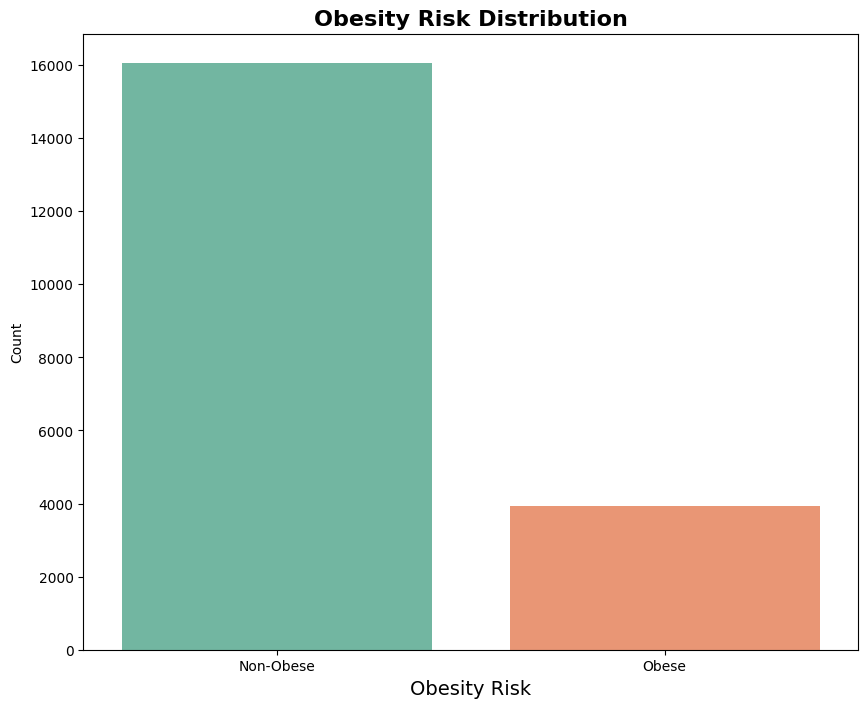

<Figure size 640x480 with 0 Axes>

In [ ]:
# Target distribution

plt.figure(figsize=(10,8))

sns.countplot(x='Obesity_Risk', data=df_eda, palette='Set2')
plt.title('Obesity Risk Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Obesity Risk', fontsize=14)
plt.ylabel('Count')
plt.show()

#Save figure
plt.savefig("/content/drive/MyDrive/Satya/Graph & Table/target_distribution.png")

## Age vs Obesity

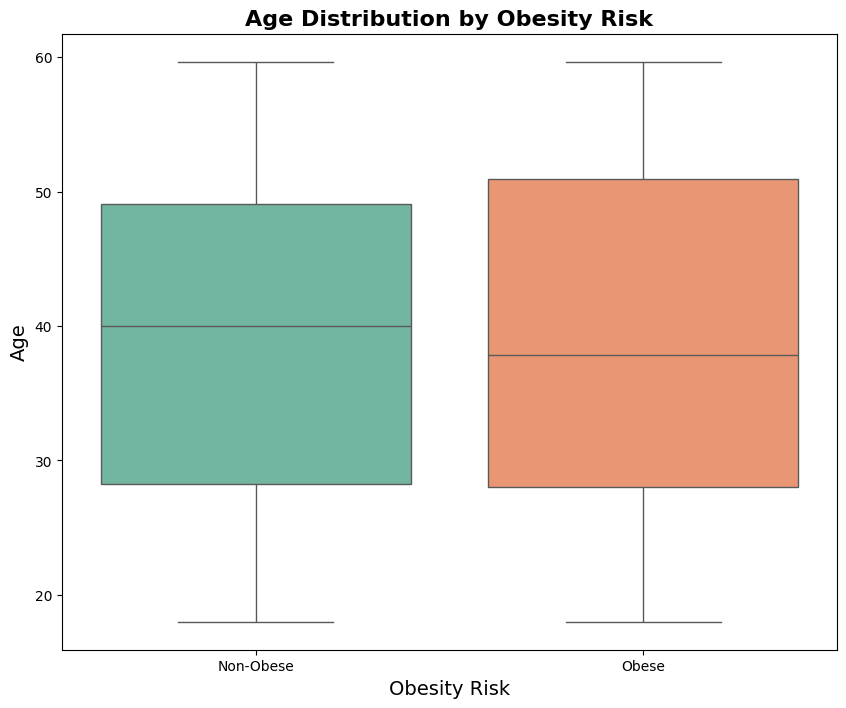

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,8))

sns.boxplot(x="Obesity_Risk", y="Age", data=df_eda, palette='Set2')
plt.title("Age Distribution by Obesity Risk", fontsize=16, fontweight='bold')
plt.xlabel("Obesity Risk", fontsize=14)
plt.ylabel("Age", fontsize=14)
plt.show()

#Save figure
plt.savefig("/content/drive/MyDrive/Satya/Graph & Table/age_vs_obesity.png")

## Correlation Analysis (Numerical Features)

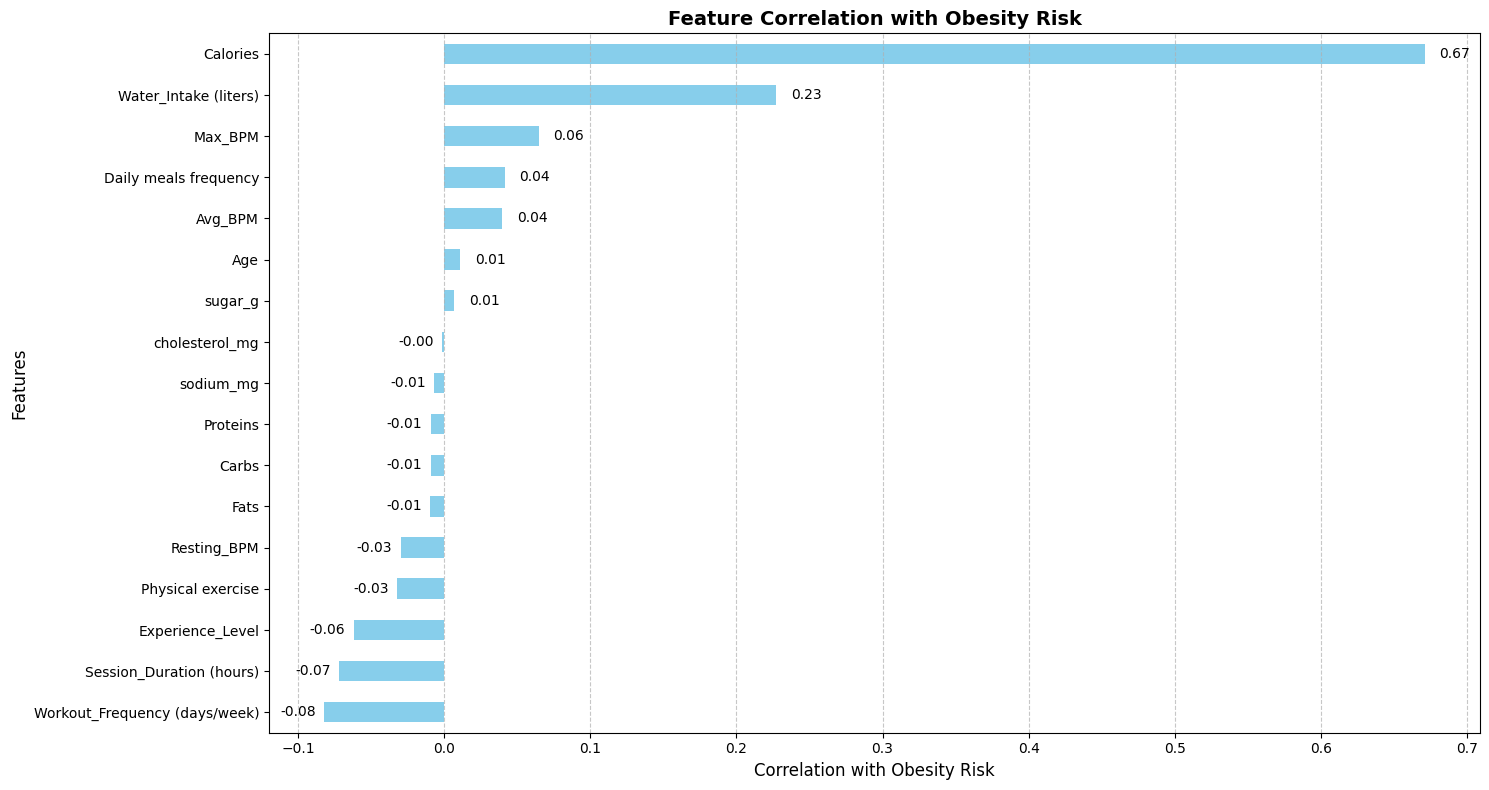

In [ ]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)

# Calculate correlation of all numeric features with 'Obesity_Risk'
corr_with_obesity = numeric_df.corr()['Obesity_Risk'].sort_values()

# Drop the correlation of 'Obesity_Risk' with itself for clarity if it's the first or last value
if 'Obesity_Risk' in corr_with_obesity.index:
    corr_with_obesity = corr_with_obesity.drop('Obesity_Risk')

plt.figure(figsize=(15,8))
ax = corr_with_obesity.plot(kind='barh', color='skyblue')

# Add value labels to the bars
for i, v in enumerate(corr_with_obesity):
    ax.text(
        v + 0.01 if v > 0 else v - 0.03,
        i,
        f"{v:.2f}",
        va='center'
    )

plt.xlabel('Correlation with Obesity Risk', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Obesity Risk', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure to Google Drive
plt.savefig("/content/drive/MyDrive/2nd Year/Semester A/Data Science Project/Generated Graph & Table/feature_correlation_with_obesity_risk.png")
plt.show()

## Feature Engineering

In [8]:
df["Macro_Total"] = df["Carbs"] + df["Proteins"] + df["Fats"]

df["HR_Range"] = df["Max_BPM"] - df["Resting_BPM"]

df.drop(columns=["Carbs", "Proteins", "Fats", "Max_BPM", "Resting_BPM"], inplace=True)

In [ ]:
df.shape

(20000, 21)

## Feature Selection

In [9]:
# Separate features and target variable
X = df.drop("Obesity_Risk", axis=1)
y = df["Obesity_Risk"]

## Identify Feature Types

In [11]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["float64","int64"]).columns

In [12]:
categorical_features

Index(['Gender', 'Workout_Type', 'meal_type', 'diet_type', 'cooking_method',
       'Difficulty Level'],
      dtype='object')

In [13]:
numerical_features

Index(['Age', 'Avg_BPM', 'Session_Duration (hours)', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level',
       'Daily meals frequency', 'Physical exercise', 'Calories', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'Macro_Total', 'HR_Range'],
      dtype='object')

## Encode Categorical Variables

In [14]:
# Convert categorical variables into dummy variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

## Scale Numerical Features

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only numerical columns
X_encoded[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

## Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Building

In [19]:
def build_models(X_train, y_train):
    """
    Train multiple classification models.

    Parameters
    ----------
    X_train : DataFrame
        Training feature matrix
    y_train : Series
        Training target variable

    Returns
    -------
    trained_models : dict
        Dictionary containing trained models
    """

    # Define models
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ),

        "CatBoost": CatBoostClassifier(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            verbose=False,
            random_state=42
        )
    }

    trained_models = {}

    # Train each model
    for name, model in models.items():

        model.fit(X_train, y_train)

        trained_models[name] = model

    return trained_models

## Train Models

In [20]:
trained_models = build_models(X_train, y_train)

In [25]:
trained_models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'CatBoost': CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_state=42, verbose=False)}

## Evaluation Function

In [21]:
def evaluate_models(trained_models, X_test, y_test):
    """
    Evaluate trained classification models.

    Parameters
    ----------
    trained_models : dict
        Dictionary of trained models
    X_test : DataFrame
        Test feature matrix
    y_test : Series
        Test target variable

    Returns
    -------
    df_results : DataFrame
        Model comparison table
    """

    results = []

    for name, model in trained_models.items():

        # Predictions
        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)[:, 1]

        # Evaluation metrics
        acc = accuracy_score(y_test, y_pred)

        prec = precision_score(y_test, y_pred)

        rec = recall_score(y_test, y_pred)

        f1 = f1_score(y_test, y_pred)

        auc = roc_auc_score(y_test, y_prob)

        results.append([
            name,
            acc,
            prec,
            rec,
            f1,
            auc
        ])

    # Create results table
    df_results = pd.DataFrame(
        results,
        columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
    )

    df_results = df_results.sort_values(
        by="ROC-AUC",
        ascending=False
    ).reset_index(drop=True)

    return df_results

## Model Performance Comparison

In [22]:
results_table = evaluate_models(trained_models, X_test, y_test)

# Sort results
df_sorted = results_table.sort_values("ROC-AUC", ascending=False)

# Highlight best model row
def highlight_best(row):
    if row.name == 0:  # first row after sorting
        return ['background-color: lightgreen; font-weight: bold'] * len(row)
    else:
        return [''] * len(row)

df_sorted.style.apply(highlight_best, axis=1)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.991000,0.978399,0.975919,0.977157,0.998875
1,CatBoost,0.986250,0.977865,0.951838,0.964676,0.998652
2,Gradient Boosting,0.942500,0.924127,0.771863,0.841160,0.980456
3,Logistic Regression,0.906750,0.838762,0.652725,0.734141,0.937983


## Model Evaluation Comparison Plot

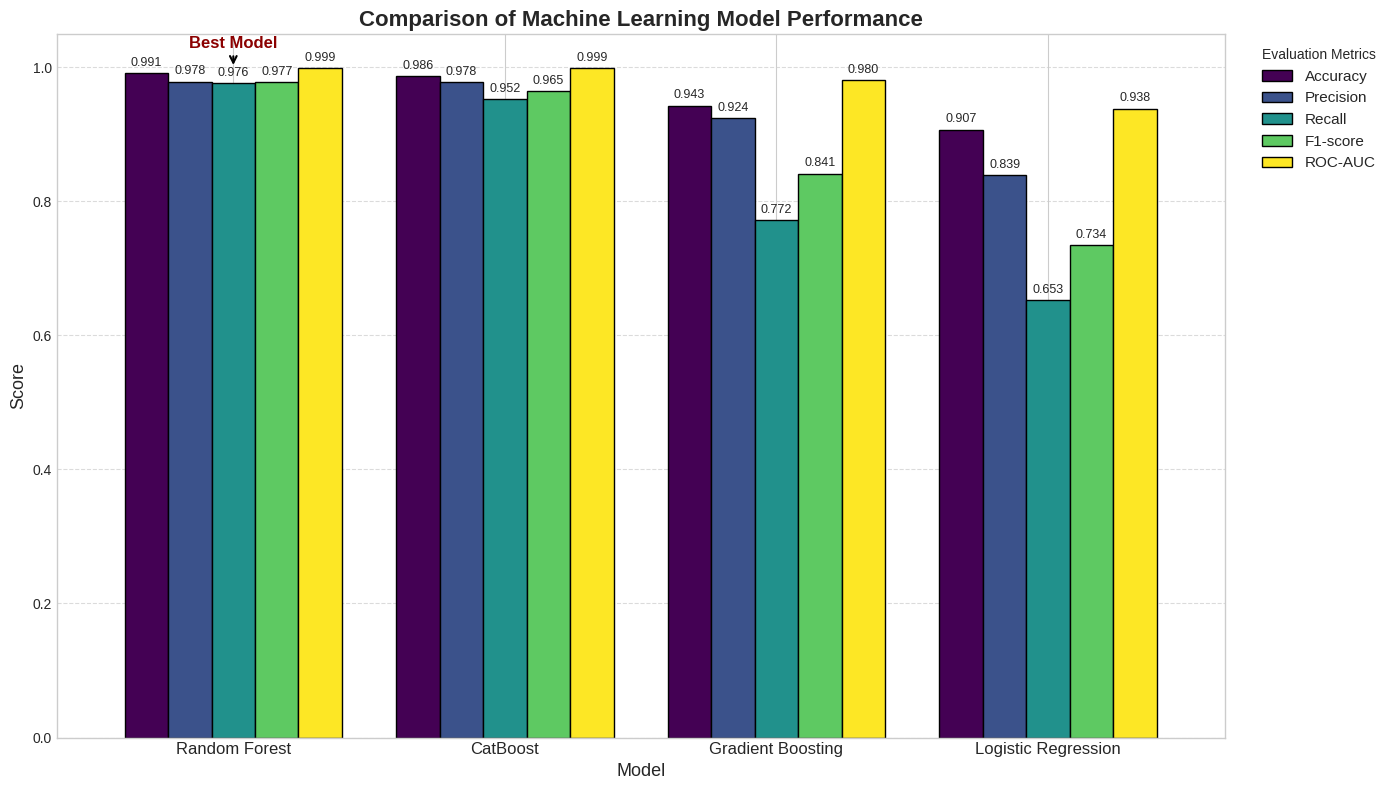

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Use a clean style
plt.style.use("seaborn-v0_8-whitegrid")

# Prepare data
plot_df = results_table.set_index("Model")

# Create figure
fig, ax = plt.subplots(figsize=(14,8))

# Plot bars
bars = plot_df.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    colormap="viridis",
    edgecolor="black"
)

# Title and labels
ax.set_title("Comparison of Machine Learning Model Performance", fontsize=16, fontweight="bold")
ax.set_ylabel("Score", fontsize=13)
ax.set_xlabel("Model", fontsize=13)

# Rotate labels
ax.set_xticklabels(plot_df.index, rotation=0, fontsize=12)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)

# Find best model based on ROC-AUC
best_model = results_table.loc[results_table["ROC-AUC"].idxmax(), "Model"]
best_score = results_table["ROC-AUC"].max()
x_pos = list(plot_df.index).index(best_model)

# Annotate best model
ax.annotate(
    "Best Model",
    xy=(x_pos, best_score),
    xytext=(x_pos, best_score + 0.03),
    arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.5),
    ha="center",
    fontsize=12,
    fontweight="bold",
    color="darkred"
)

# Improve legend
ax.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    fontsize=11
)

# Add horizontal grid
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("/content/drive/MyDrive/Satya/Graph & Table/model_performance_comparison.png")
plt.tight_layout()
plt.show()

## ROC Curve

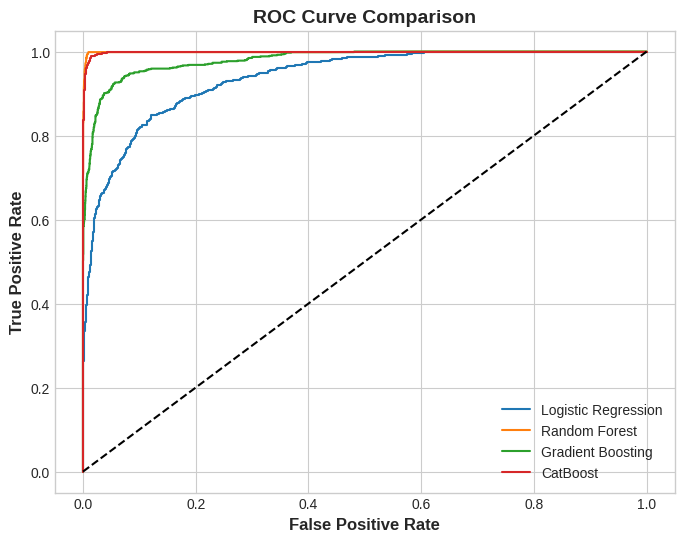

In [ ]:
plt.figure(figsize=(8,6))

for name,model in trained_models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr,tpr,_ = roc_curve(y_test,y_prob)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.title("ROC Curve Comparison", fontsize=14, fontweight="bold")
plt.legend()
plt.savefig("/content/drive/MyDrive/Satya/Graph & Table/roc_curve.png")
plt.show()

## Check Overfitting for the Best Model

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Identify best model based on ROC-AUC
best_model_name = results_table.loc[results_table["ROC-AUC"].idxmax(), "Model"]
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")

# Predictions on training data
y_train_pred = best_model.predict(X_train)
y_train_prob = best_model.predict_proba(X_train)[:, 1]

# Predictions on test data
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# Training performance
train_acc = accuracy_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

# Testing performance
test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

# Print results
print("\nTraining Performance")
print("--------------------")
print(f"Accuracy : {train_acc:.4f}")
print(f"ROC-AUC  : {train_auc:.4f}")

print("\nTest Performance")
print("--------------------")
print(f"Accuracy : {test_acc:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

# Overfitting check
print("\nOverfitting Check")
print("--------------------")
print(f"Accuracy Gap : {abs(train_acc - test_acc):.4f}")
print(f"AUC Gap      : {abs(train_auc - test_auc):.4f}")

Best Model: Random Forest

Training Performance
--------------------
Accuracy : 1.0000
ROC-AUC  : 1.0000

Test Performance
--------------------
Accuracy : 0.9910
ROC-AUC  : 0.9989

Overfitting Check
--------------------
Accuracy Gap : 0.0090
AUC Gap      : 0.0011


In [ ]:
from sklearn.model_selection import cross_val_score
from catboost import CatBoostClassifier

model = CatBoostClassifier(verbose=False)

scores = cross_val_score(model, X_encoded, y, cv=5, scoring="roc_auc")

print("CV AUC scores:", scores)
print("Mean AUC:", scores.mean())

CV AUC scores: [0.99913755 0.99930846 0.99971423 0.99894651 0.99951529]
Mean AUC: 0.9993244072676347


## Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(
    rf_model,
    X_encoded,
    y,
    cv=5,
    scoring="roc_auc"
)

# Create results table
cv_results = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(cv_scores))],
    "ROC-AUC": cv_scores
})

print("Cross-Validation Results")
print(cv_results)

print("\nSummary Statistics")
print("-------------------")
print(f"Mean ROC-AUC : {np.mean(cv_scores):.4f}")
print(f"Std Dev      : {np.std(cv_scores):.4f}")

Cross-Validation Results
     Fold   ROC-AUC
0  Fold 1  0.998886
1  Fold 2  0.998918
2  Fold 3  0.999637
3  Fold 4  0.998719
4  Fold 5  0.999496

Summary Statistics
-------------------
Mean ROC-AUC : 0.9991
Std Dev      : 0.0004


## Hyperparameter Tuning to get best parameter

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define base model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Randomized Search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,              # number of parameter combinations
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

# Fit model
rf_random.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", rf_random.best_params_)

# Best model
best_rf = rf_random.best_estimator_

print("Best CV Score:", rf_random.best_score_)

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV Score: 0.9992888962560814


## Best Parameters

In [ ]:
rf_random.best_params_

{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

## Retrain Random Forest Using Best Parameters

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model with best parameters
best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Train model
best_rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=2, n_estimators=500, random_state=42)

## Make Predictions

In [18]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

## Evaluate the Retrained Model

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Create a new row with tuned model results
tuned_result = pd.DataFrame({
    "Model": ["Random Forest (Tuned)"],
    "Accuracy": [acc],
    "Precision": [prec],
    "Recall": [rec],
    "F1-score": [f1],
    "ROC-AUC": [auc]
})

# Combine with existing results table
df_updated = pd.concat([df_sorted.reset_index(drop=True), tuned_result], ignore_index=True)

# Sort again by ROC-AUC
df_updated = df_updated.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

# Display updated table
df_updated

# Find index of best model based on ROC-AUC
best_idx = df_updated["ROC-AUC"].idxmax()

# Function to highlight best row
def highlight_best_row(row):
    if row.name == best_idx:
        return ["background-color: lightgreen; font-weight: bold"] * len(row)
    else:
        return [""] * len(row)

# Apply style
df_updated.style.apply(highlight_best_row, axis=1)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.991000,0.978399,0.975919,0.977157,0.998875
1,CatBoost,0.986250,0.977865,0.951838,0.964676,0.998652
2,Random Forest (Tuned),0.990750,0.980818,0.972117,0.976448,0.998421
3,Gradient Boosting,0.942500,0.924127,0.771863,0.841160,0.980456
4,Logistic Regression,0.906750,0.838762,0.652725,0.734141,0.937983


In [30]:
random_forest_Initial = trained_models['Random Forest']

print(random_forest_Initial)

RandomForestClassifier(n_estimators=200, random_state=42)


## Permutation-Based Feature Importance of Lifestyle Predictors for Obesity Risk

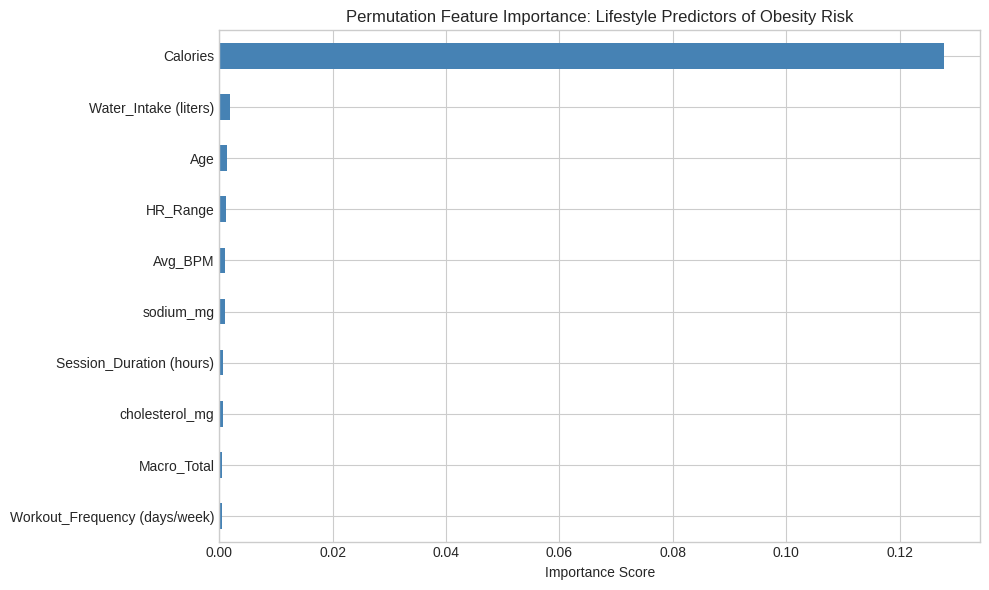

In [28]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calculate permutation importance
perm = permutation_importance(
    random_forest_Initial,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

# Create importance dataframe
importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

# Plot top features
plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind="barh",
    color="steelblue"
)

plt.title("Permutation Feature Importance: Lifestyle Predictors of Obesity Risk")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()